DATASET READY
Final shape: (10000, 22)
Positive label rate: 0.3397
Week range: 9 to 50


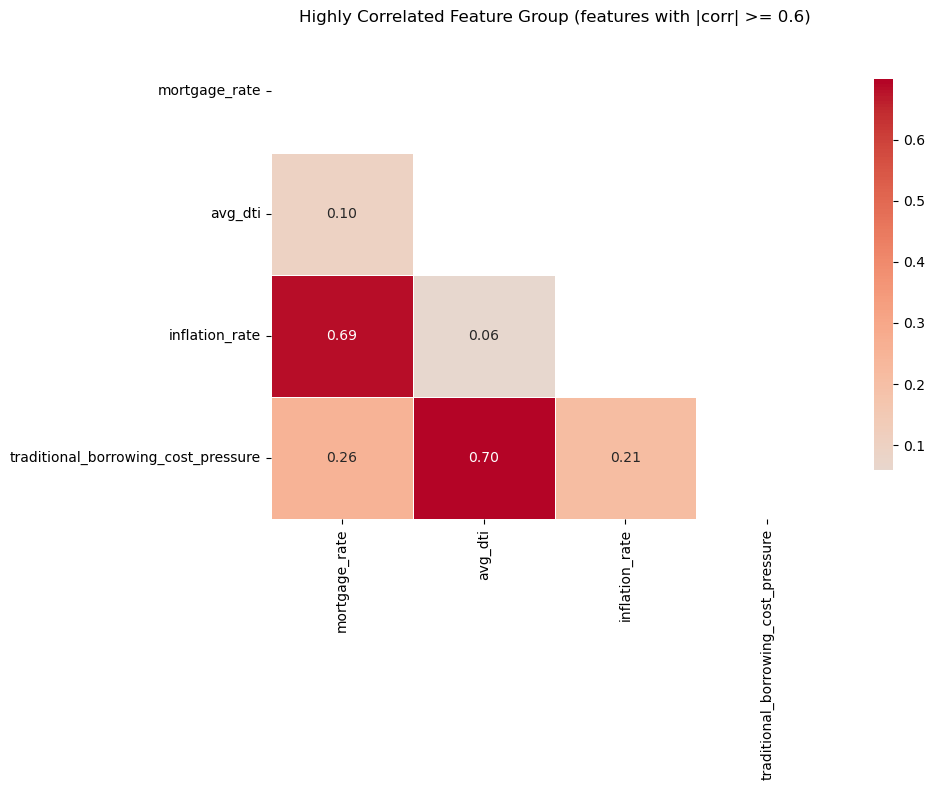

  0%|          | 0/30 [00:00<?, ?it/s]


XGBOOST MODEL SUMMARY
Split method: Random stratified split
Train size:      6000
Validation size: 2000
Test size:       2000
Train positive rate:      0.3398
Validation positive rate: 0.3395
Test positive rate:       0.3395
Best validation ROC-AUC from Optuna: 0.7518
Selected threshold from validation set: 0.48

Performance Metrics:
            Train  Validation    Test
Accuracy   0.7085      0.6540  0.6315
Precision  0.5445      0.4939  0.4744
Recall     0.8700      0.7747  0.7909
F1         0.6698      0.6032  0.5930
ROC-AUC    0.8421      0.7518  0.7342
PR-AUC     0.7285      0.6010  0.5835
Logloss    0.5421      0.5976  0.6178

Test Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0          726          595
Actual 1          142          537


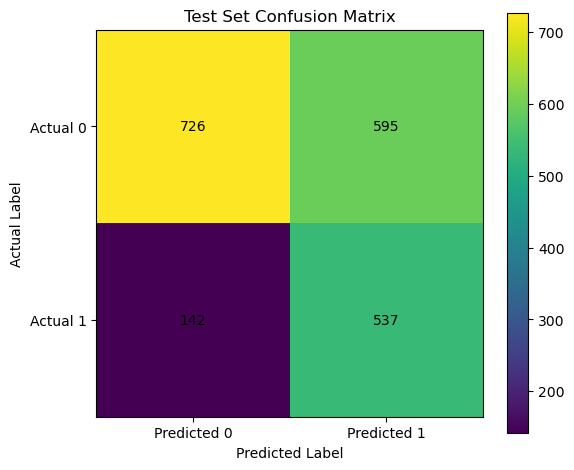

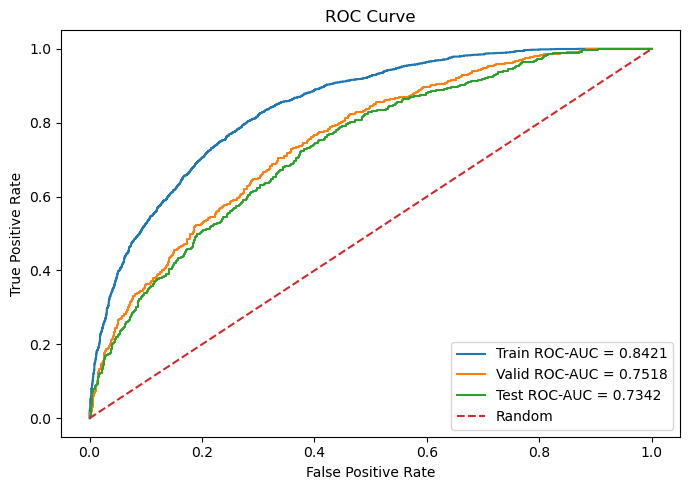

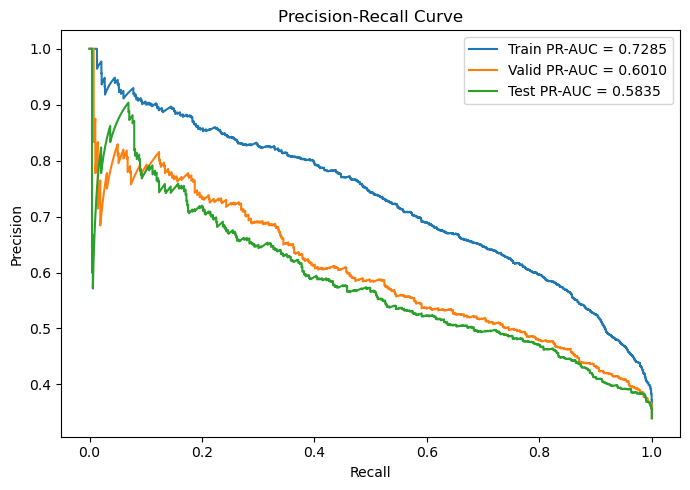

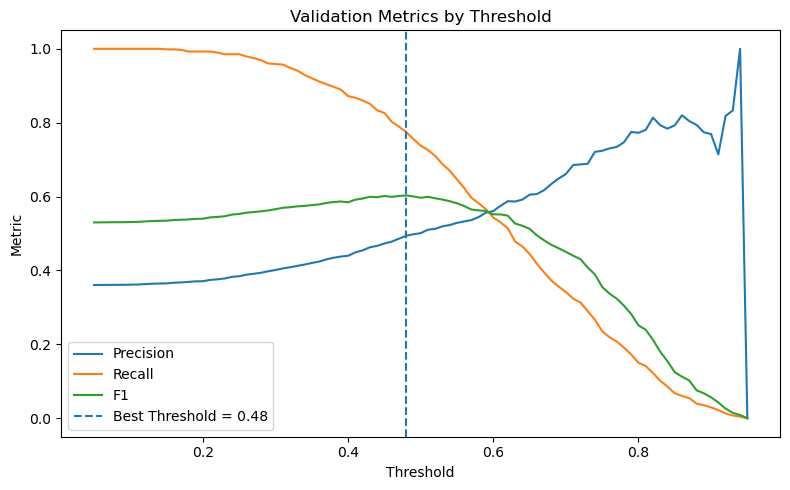


TOP FEATURE IMPORTANCE
           original_feature  importance  importance_pct
                      state      0.3364          0.3364
                     region      0.1271          0.1271
             submarket_type      0.1121          0.1121
             website_visits      0.0612          0.0612
             avg_home_value      0.0572          0.0572
              median_income      0.0404          0.0404
home_price_appreciation_yoy      0.0255          0.0255
             inflation_rate      0.0225          0.0225
     dominant_property_type      0.0214          0.0214
                    avg_dti      0.0214          0.0214
  consumer_confidence_index      0.0208          0.0208
           avg_credit_score      0.0201          0.0201
 property_eligibility_score      0.0195          0.0195
                   ad_spend      0.0188          0.0188
                    avg_ltv      0.0182          0.0182

TOP 8 FEATURE IMPORTANCE
           original_feature  importance  importance_pc

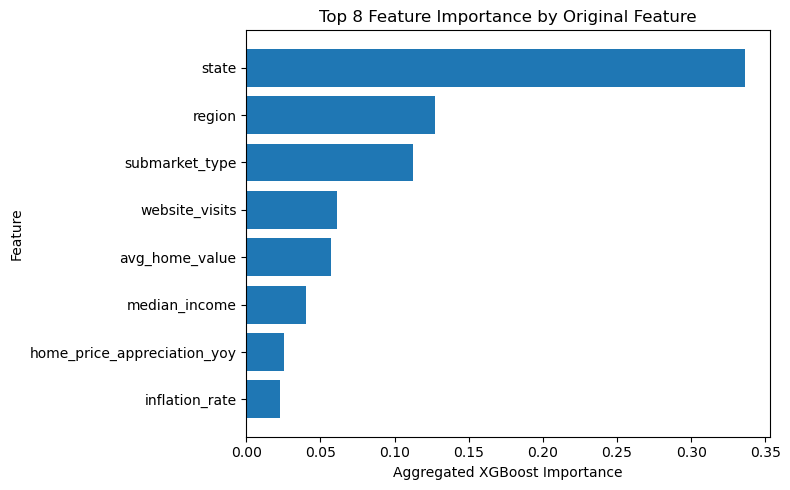


BOTTOM 8 FEATURE IMPORTANCE
                   original_feature  importance  importance_pct
         property_eligibility_score      0.0195          0.0195
                           ad_spend      0.0188          0.0188
                            avg_ltv      0.0182          0.0182
                      mortgage_rate      0.0169          0.0169
               owner_occupancy_rate      0.0169          0.0169
            local_unemployment_rate      0.0166          0.0166
           housing_inventory_months      0.0138          0.0138
traditional_borrowing_cost_pressure      0.0133          0.0133


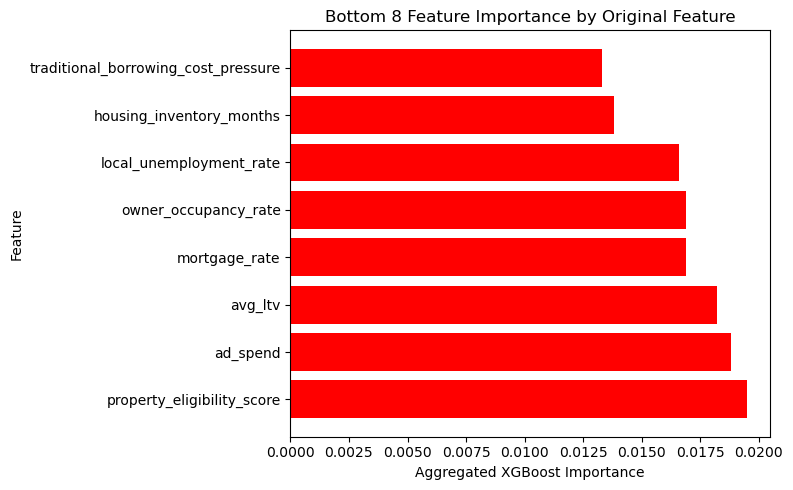

In [ ]:
# ============================================================
# Blocks:
#   1. Random Data Simulation
#   2. Quantifying Demand
#   3. Missing Value Handling
#   4. XGBoost Model Fitting
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



# ============================================================
# 1. Random Data Simulation
# ============================================================

states = [
    "Arizona", "California", "Connecticut", "Oregon", "Washington",
    "Illinois", "Massachusetts", "Maryland", "New Jersey", "New York",
    "Pennsylvania", "Virginia", "Florida", "Georgia", "Ohio", "Michigan",
    "Minnesota", "Nevada", "Colorado", "North Carolina", "Missouri",
    "Delaware", "Indiana", "Kansas", "Kentucky", "New Mexico",
    "South Carolina", "Tennessee", "Utah", "Wisconsin", "Washington DC"
]

region_map = {
    "California": "West",
    "Oregon": "West",
    "Washington": "West",

    "Arizona": "Mountain",
    "Nevada": "Mountain",
    "Colorado": "Mountain",
    "Utah": "Mountain",
    "New Mexico": "Mountain",

    "Connecticut": "Northeast",
    "Massachusetts": "Northeast",
    "New Jersey": "Northeast",
    "New York": "Northeast",
    "Pennsylvania": "Northeast",

    "Illinois": "Midwest",
    "Ohio": "Midwest",
    "Michigan": "Midwest",
    "Minnesota": "Midwest",
    "Missouri": "Midwest",
    "Indiana": "Midwest",
    "Kansas": "Midwest",
    "Wisconsin": "Midwest",

    "Florida": "South",
    "Georgia": "South",
    "North Carolina": "South",
    "South Carolina": "South",
    "Tennessee": "South",
    "Kentucky": "South",
    "Virginia": "South",
    "Maryland": "South",
    "Delaware": "South",

    "Washington DC": "DC_Metro",
}

submarket_types = [
    "high_cost_urban",
    "affluent_suburban",
    "middle_income_suburban",
    "growing_sunbelt_metro",
    "coastal_premium",
    "inland_value_market",
    "retirement_cashout_market",
    "emerging_growth_market",
]

property_type_options = {
    "high_cost_urban": ["condo", "townhome", "mixed"],
    "affluent_suburban": ["single_family", "townhome", "mixed"],
    "middle_income_suburban": ["single_family", "townhome", "mixed"],
    "growing_sunbelt_metro": ["single_family", "townhome", "mixed"],
    "coastal_premium": ["single_family", "condo", "mixed"],
    "inland_value_market": ["single_family", "townhome"],
    "retirement_cashout_market": ["single_family", "condo", "mixed"],
    "emerging_growth_market": ["single_family", "townhome", "mixed"],
}

property_type_probs = {
    "high_cost_urban": [0.45, 0.30, 0.25],
    "affluent_suburban": [0.70, 0.20, 0.10],
    "middle_income_suburban": [0.65, 0.25, 0.10],
    "growing_sunbelt_metro": [0.60, 0.20, 0.20],
    "coastal_premium": [0.50, 0.25, 0.25],
    "inland_value_market": [0.80, 0.20],
    "retirement_cashout_market": [0.65, 0.20, 0.15],
    "emerging_growth_market": [0.55, 0.25, 0.20],
}

n_weeks = 50
weeks = np.arange(1, n_weeks + 1)


state_home_value_base = {
    "California": 850000,
    "New York": 650000,
    "Massachusetts": 700000,
    "New Jersey": 600000,
    "Washington": 650000,
    "Oregon": 550000,
    "Colorado": 600000,
    "Connecticut": 520000,
    "Maryland": 470000,
    "Virginia": 460000,
    "Washington DC": 750000,
    "Florida": 450000,
    "Arizona": 420000,
    "Nevada": 430000,
    "Utah": 500000,
    "North Carolina": 380000,
    "Georgia": 350000,
    "South Carolina": 330000,
    "Tennessee": 340000,
    "Delaware": 360000,
    "Pennsylvania": 340000,
    "Illinois": 330000,
    "Minnesota": 360000,
    "Wisconsin": 310000,
    "Ohio": 280000,
    "Michigan": 290000,
    "Missouri": 280000,
    "Indiana": 260000,
    "Kansas": 260000,
    "Kentucky": 250000,
    "New Mexico": 300000,
}

state_income_base = {
    "California": 95000,
    "New York": 90000,
    "Massachusetts": 98000,
    "New Jersey": 96000,
    "Washington": 94000,
    "Oregon": 82000,
    "Colorado": 92000,
    "Connecticut": 94000,
    "Maryland": 93000,
    "Virginia": 90000,
    "Washington DC": 105000,
    "Florida": 76000,
    "Arizona": 76000,
    "Nevada": 74000,
    "Utah": 85000,
    "North Carolina": 74000,
    "Georgia": 73000,
    "South Carolina": 68000,
    "Tennessee": 69000,
    "Delaware": 77000,
    "Pennsylvania": 76000,
    "Illinois": 79000,
    "Minnesota": 83000,
    "Wisconsin": 74000,
    "Ohio": 70000,
    "Michigan": 70000,
    "Missouri": 69000,
    "Indiana": 68000,
    "Kansas": 69000,
    "Kentucky": 65000,
    "New Mexico": 66000,
}

state_unemployment_base = {
    "California": 5.1,
    "New York": 4.6,
    "Massachusetts": 3.8,
    "New Jersey": 4.4,
    "Washington": 4.5,
    "Oregon": 4.2,
    "Colorado": 3.6,
    "Connecticut": 4.0,
    "Maryland": 3.4,
    "Virginia": 3.2,
    "Washington DC": 5.0,
    "Florida": 3.5,
    "Arizona": 3.8,
    "Nevada": 5.0,
    "Utah": 3.0,
    "North Carolina": 3.6,
    "Georgia": 3.5,
    "South Carolina": 3.4,
    "Tennessee": 3.3,
    "Delaware": 4.0,
    "Pennsylvania": 4.1,
    "Illinois": 4.8,
    "Minnesota": 3.3,
    "Wisconsin": 3.2,
    "Ohio": 4.0,
    "Michigan": 4.3,
    "Missouri": 3.7,
    "Indiana": 3.8,
    "Kansas": 3.5,
    "Kentucky": 4.1,
    "New Mexico": 4.5,
}

state_market_size = {
    "California": 1.80,
    "Florida": 1.45,
    "New York": 1.35,
    "New Jersey": 1.05,
    "Washington": 1.05,
    "Massachusetts": 1.00,
    "Arizona": 1.00,
    "North Carolina": 1.00,
    "Georgia": 0.95,
    "Virginia": 0.95,
    "Colorado": 0.90,
    "Pennsylvania": 0.90,
    "Illinois": 0.90,
    "Maryland": 0.85,
    "Oregon": 0.80,
    "Tennessee": 0.80,
    "Ohio": 0.78,
    "Michigan": 0.75,
    "Minnesota": 0.72,
    "South Carolina": 0.70,
    "Wisconsin": 0.68,
    "Nevada": 0.68,
    "Utah": 0.68,
    "Connecticut": 0.65,
    "Missouri": 0.65,
    "Indiana": 0.62,
    "Kentucky": 0.58,
    "Kansas": 0.55,
    "New Mexico": 0.50,
    "Delaware": 0.45,
    "Washington DC": 0.42,
}

home_value_multiplier = {
    "high_cost_urban": 1.35,
    "affluent_suburban": 1.25,
    "middle_income_suburban": 1.00,
    "growing_sunbelt_metro": 1.05,
    "coastal_premium": 1.45,
    "inland_value_market": 0.75,
    "retirement_cashout_market": 1.10,
    "emerging_growth_market": 0.90,
}

income_multiplier = {
    "high_cost_urban": 1.20,
    "affluent_suburban": 1.35,
    "middle_income_suburban": 1.00,
    "growing_sunbelt_metro": 1.05,
    "coastal_premium": 1.30,
    "inland_value_market": 0.85,
    "retirement_cashout_market": 0.90,
    "emerging_growth_market": 0.95,
}

hpa_submarket_effect = {
    "high_cost_urban": 0.2,
    "affluent_suburban": 0.8,
    "middle_income_suburban": 0.5,
    "growing_sunbelt_metro": 1.8,
    "coastal_premium": 0.7,
    "inland_value_market": 0.1,
    "retirement_cashout_market": 0.4,
    "emerging_growth_market": 1.3,
}

unemployment_submarket_effect = {
    "high_cost_urban": 0.2,
    "affluent_suburban": -0.5,
    "middle_income_suburban": 0.0,
    "growing_sunbelt_metro": -0.1,
    "coastal_premium": -0.3,
    "inland_value_market": 0.4,
    "retirement_cashout_market": 0.1,
    "emerging_growth_market": 0.3,
}

equity_submarket_effect = {
    "high_cost_urban": 0.00,
    "affluent_suburban": 0.06,
    "middle_income_suburban": 0.02,
    "growing_sunbelt_metro": 0.01,
    "coastal_premium": 0.05,
    "inland_value_market": 0.03,
    "retirement_cashout_market": 0.10,
    "emerging_growth_market": -0.01,
}

traffic_multiplier = {
    "high_cost_urban": 1.30,
    "affluent_suburban": 1.15,
    "middle_income_suburban": 1.00,
    "growing_sunbelt_metro": 1.25,
    "coastal_premium": 1.20,
    "inland_value_market": 0.75,
    "retirement_cashout_market": 0.90,
    "emerging_growth_market": 1.05,
}


rate_random_walk = np.cumsum(np.random.normal(0, 0.040, size=n_weeks))
inflation_random_walk = np.cumsum(np.random.normal(0, 0.025, size=n_weeks))

weekly_macro = pd.DataFrame({"week": weeks})

weekly_macro["mortgage_rate_base"] = (
    6.6
    + 0.25 * np.sin(weeks / 7.5)
    + rate_random_walk
    + np.random.normal(0, 0.07, size=n_weeks)
).clip(5.7, 7.6)

weekly_macro["inflation_rate_base"] = (
    3.2
    + 0.18 * np.sin(weeks / 10.0 + 0.5)
    + inflation_random_walk
    + np.random.normal(0, 0.05, size=n_weeks)
).clip(2.2, 4.8)

weekly_macro["consumer_confidence_base"] = (
    105
    - 4.0 * (weekly_macro["mortgage_rate_base"] - 6.5)
    - 3.0 * (weekly_macro["inflation_rate_base"] - 3.0)
    + 2.5 * np.sin(weeks / 8.0)
    + np.random.normal(0, 3.0, size=n_weeks)
).clip(70, 120)

weekly_macro["seasonality"] = (
    0.15 * np.sin(2 * np.pi * weeks / 52)
    + 0.05 * np.cos(2 * np.pi * weeks / 26)
)


rows = []

for state in states:
    region = region_map[state]

    for submarket_type in submarket_types:
        dominant_property_type = np.random.choice(
            property_type_options[submarket_type],
            p=property_type_probs[submarket_type],
        )

        for week in weeks:
            rows.append({
                "state": state,
                "region": region,
                "submarket_type": submarket_type,
                "dominant_property_type": dominant_property_type,
                "week": week,
            })

df = pd.DataFrame(rows)
df = df.merge(weekly_macro, on="week", how="left")

df["state_home_value_base"] = df["state"].map(state_home_value_base)
df["state_income_base"] = df["state"].map(state_income_base)
df["state_unemployment_base"] = df["state"].map(state_unemployment_base)
df["state_market_size"] = df["state"].map(state_market_size)

df["home_value_multiplier"] = df["submarket_type"].map(home_value_multiplier)
df["income_multiplier"] = df["submarket_type"].map(income_multiplier)
df["hpa_submarket_effect"] = df["submarket_type"].map(hpa_submarket_effect)
df["unemployment_submarket_effect"] = df["submarket_type"].map(unemployment_submarket_effect)
df["equity_submarket_effect"] = df["submarket_type"].map(equity_submarket_effect)
df["traffic_multiplier"] = df["submarket_type"].map(traffic_multiplier)


df["mortgage_rate"] = (
    df["mortgage_rate_base"]
    + np.random.normal(0, 0.12, size=len(df))
).clip(5.7, 7.7)

df["inflation_rate"] = (
    df["inflation_rate_base"]
    + np.random.normal(0, 0.08, size=len(df))
).clip(2.1, 4.9)

region_confidence_effect = {
    "West": 0.0,
    "Mountain": 1.5,
    "Northeast": -0.5,
    "Midwest": -1.0,
    "South": 1.0,
    "DC_Metro": -0.5,
}

df["consumer_confidence_index"] = (
    df["consumer_confidence_base"]
    + df["region"].map(region_confidence_effect)
    + np.random.normal(0, 4.0, size=len(df))
).clip(70, 120)

df["local_unemployment_rate"] = (
    df["state_unemployment_base"]
    + df["unemployment_submarket_effect"]
    + 0.12 * (df["inflation_rate"] - 3.2)
    + np.random.normal(0, 0.55, size=len(df))
).clip(2.4, 8.5)

region_hpa_effect = {
    "West": 0.4,
    "Mountain": 0.9,
    "Northeast": 0.1,
    "Midwest": -0.1,
    "South": 0.8,
    "DC_Metro": 0.2,
}

initial_hpa = (
    3.2
    + df["region"].map(region_hpa_effect)
    + df["hpa_submarket_effect"]
    - 0.65 * (df["mortgage_rate"] - 6.5)
    + 0.04 * (df["consumer_confidence_index"] - 100)
    + np.random.normal(0, 2.2, size=len(df))
).clip(-5.0, 12.0)

inventory_submarket_effect = {
    "high_cost_urban": 0.2,
    "affluent_suburban": -0.3,
    "middle_income_suburban": 0.0,
    "growing_sunbelt_metro": -0.2,
    "coastal_premium": -0.4,
    "inland_value_market": 0.5,
    "retirement_cashout_market": 0.1,
    "emerging_growth_market": 0.2,
}

df["housing_inventory_months"] = (
    4.1
    + df["submarket_type"].map(inventory_submarket_effect)
    + 0.25 * (df["mortgage_rate"] - 6.5)
    - 0.18 * (initial_hpa - 3.0)
    + np.random.normal(0, 0.70, size=len(df))
).clip(1.0, 7.5)

df["home_price_appreciation_yoy"] = (
    3.2
    + df["region"].map(region_hpa_effect)
    + df["hpa_submarket_effect"]
    - 0.65 * (df["mortgage_rate"] - 6.5)
    - 0.18 * (df["housing_inventory_months"] - 4.0)
    + 0.04 * (df["consumer_confidence_index"] - 100)
    + np.random.normal(0, 2.2, size=len(df))
).clip(-5.0, 12.0)

df["avg_home_value"] = (
    df["state_home_value_base"]
    * df["home_value_multiplier"]
    * np.random.lognormal(mean=0.0, sigma=0.30, size=len(df))
    * (1 + df["home_price_appreciation_yoy"] / 100 * 0.15)
).clip(180000, 1500000)

df["avg_home_equity_pct"] = (
    0.36
    + df["equity_submarket_effect"]
    + 0.012 * df["home_price_appreciation_yoy"]
    - 0.010 * (df["mortgage_rate"] - 6.5)
    + np.random.normal(0, 0.080, size=len(df))
).clip(0.15, 0.75)

df["avg_ltv"] = (
    1.0
    - df["avg_home_equity_pct"]
    + np.random.normal(0, 0.073, size=len(df))
).clip(0.25, 0.85)

property_owner_base = {
    "single_family": 0.84,
    "townhome": 0.76,
    "condo": 0.65,
    "mixed": 0.72,
}

submarket_owner_effect = {
    "high_cost_urban": -0.04,
    "affluent_suburban": 0.05,
    "middle_income_suburban": 0.03,
    "growing_sunbelt_metro": 0.02,
    "coastal_premium": 0.00,
    "inland_value_market": 0.04,
    "retirement_cashout_market": 0.03,
    "emerging_growth_market": 0.00,
}

df["owner_occupancy_rate"] = (
    df["dominant_property_type"].map(property_owner_base)
    + df["submarket_type"].map(submarket_owner_effect)
    + np.random.normal(0, 0.063, size=len(df))
).clip(0.55, 0.95)

df["median_income"] = (
    df["state_income_base"]
    * df["income_multiplier"]
    * np.random.lognormal(mean=0.0, sigma=0.18, size=len(df))
).clip(45000, 180000)

credit_submarket_effect = {
    "high_cost_urban": 5,
    "affluent_suburban": 25,
    "middle_income_suburban": 5,
    "growing_sunbelt_metro": 3,
    "coastal_premium": 18,
    "inland_value_market": -5,
    "retirement_cashout_market": 8,
    "emerging_growth_market": -3,
}

df["avg_credit_score"] = (
    690
    + 0.00032 * (df["median_income"] - 80000)
    - 7.0 * (df["local_unemployment_rate"] - 4.0)
    + df["submarket_type"].map(credit_submarket_effect)
    + np.random.normal(0, 35, size=len(df))
).clip(600, 805)

income_strength = (
    df["median_income"] - df["median_income"].mean()
) / df["median_income"].std()

home_value_pressure = (
    df["avg_home_value"] - df["avg_home_value"].mean()
) / df["avg_home_value"].std()

df["avg_dti"] = (
    0.35
    + 0.018 * (df["mortgage_rate"] - 6.5)
    + 0.018 * home_value_pressure
    - 0.025 * income_strength
    + 0.010 * (df["local_unemployment_rate"] - 4.0)
    + np.random.normal(0, 0.060, size=len(df))
).clip(0.18, 0.58)

df["traditional_borrowing_cost_pressure"] = (
    0.45 * (df["mortgage_rate"] - 6.5)
    + 0.30 * (df["inflation_rate"] - 3.0)
    + 0.65 * ((df["avg_dti"] - df["avg_dti"].mean()) / df["avg_dti"].std())
    - 0.018 * (df["consumer_confidence_index"] - 100)
    + np.random.normal(0, 0.55, size=len(df))
).clip(-3.0, 3.0)

property_type_eligibility_effect = {
    "single_family": 0.25,
    "townhome": 0.10,
    "condo": -0.05,
    "mixed": -0.10,
}

df["property_eligibility_score"] = (
    0.55 * ((df["owner_occupancy_rate"] - df["owner_occupancy_rate"].mean()) / df["owner_occupancy_rate"].std())
    + 0.35 * ((df["avg_credit_score"] - df["avg_credit_score"].mean()) / df["avg_credit_score"].std())
    - 0.40 * ((df["avg_dti"] - df["avg_dti"].mean()) / df["avg_dti"].std())
    - 0.20 * ((df["housing_inventory_months"] - df["housing_inventory_months"].mean()) / df["housing_inventory_months"].std())
    + 0.18 * ((df["home_price_appreciation_yoy"] - df["home_price_appreciation_yoy"].mean()) / df["home_price_appreciation_yoy"].std())
    + df["dominant_property_type"].map(property_type_eligibility_effect)
    + np.random.normal(0, 0.55, size=len(df))
).clip(-3.0, 3.0)

df["website_visits"] = np.exp(
    np.log(2500)
    + np.log(df["state_market_size"])
    + np.log(df["traffic_multiplier"])
    + 0.010 * (df["consumer_confidence_index"] - 100)
    + df["seasonality"]
    + np.random.normal(0, 0.60, size=len(df))
)

df["website_visits"] = (
    df["website_visits"]
    .clip(200, 20000)
    .round()
    .astype(int)
)

df["ad_spend"] = (
    9000
    * df["state_market_size"]
    * (df["avg_home_value"] / 450000) ** 0.35
    * df["traffic_multiplier"]
    * np.random.lognormal(mean=0.0, sigma=0.65, size=len(df))
).clip(1000, 80000)

expected_leads = (
    0.018 * df["website_visits"]
    + 0.0012 * df["ad_spend"]
    + 18.0 * df["avg_home_equity_pct"]
    + 1.8 * df["home_price_appreciation_yoy"].clip(-2, 10)
    + 0.15 * (df["consumer_confidence_index"] - 90)
    - 2.2 * (df["mortgage_rate"] - 6.5)
)

expected_leads = (
    expected_leads
    * np.random.lognormal(mean=0.0, sigma=0.30, size=len(df))
).clip(3, 700)

df["lead_volume"] = (
    np.random.poisson(expected_leads)
    .clip(1, 800)
    .astype(int)
)

feature_cols = [
    "state",
    "region",
    "submarket_type",
    "dominant_property_type",
    "mortgage_rate",
    "inflation_rate",
    "consumer_confidence_index",
    "local_unemployment_rate",
    "home_price_appreciation_yoy",
    "housing_inventory_months",
    "avg_home_value",
    "avg_ltv",
    "owner_occupancy_rate",
    "median_income",
    "avg_credit_score",
    "avg_dti",
    "traditional_borrowing_cost_pressure",
    "property_eligibility_score",
    "website_visits",
    "ad_spend",
]

df = df[feature_cols + ["avg_home_equity_pct", "lead_volume", "week"]].copy()





# ============================================================
# 2. Quantifying Demand
# ============================================================

def zscore(series):
    std = series.std()
    if std == 0 or pd.isna(std):
        return series * 0.0
    return (series - series.mean()) / std


UNISON_RISK_ADJUSTMENT = 0.05
UNISON_MIN_INVESTMENT = 30000
UNISON_MAX_INVESTMENT = 500000
UNISON_MAX_INVESTMENT_PCT = 0.15

df["estimated_appraised_value"] = df["avg_home_value"]

df["original_agreed_value"] = (
    df["estimated_appraised_value"] * (1 - UNISON_RISK_ADJUSTMENT)
)

df["max_investment_by_pct"] = (
    df["original_agreed_value"] * UNISON_MAX_INVESTMENT_PCT
)

df["max_feasible_investment_amount"] = np.minimum(
    df["max_investment_by_pct"],
    UNISON_MAX_INVESTMENT,
)

df["investment_amount_feasible"] = (
    df["max_feasible_investment_amount"] >= UNISON_MIN_INVESTMENT
).astype(int)

df["expected_investment_pct"] = (
    np.random.normal(loc=0.095, scale=0.025, size=len(df))
).clip(0.05, UNISON_MAX_INVESTMENT_PCT)

df["raw_expected_investment_amount"] = (
    df["original_agreed_value"] * df["expected_investment_pct"]
)

df["expected_investment_amount"] = np.where(
    df["investment_amount_feasible"] == 1,
    np.maximum(df["raw_expected_investment_amount"], UNISON_MIN_INVESTMENT),
    0,
)

df["expected_investment_amount"] = np.minimum(
    df["expected_investment_amount"],
    df["max_feasible_investment_amount"],
)


n = len(df)

cashout_need_base = np.random.normal(0, 1.0, size=n)
lead_quality_base = np.random.normal(0, 1.0, size=n)
underwriting_fit_base = np.random.normal(0, 1.0, size=n)

df["homeowner_cashout_need"] = (
    0.90 * cashout_need_base
    + 0.04 * zscore(df["traditional_borrowing_cost_pressure"])
    + 0.03 * zscore(df["inflation_rate"])
    + 0.03 * zscore(df["mortgage_rate"])
)

df["channel_lead_quality"] = (
    0.90 * lead_quality_base
    + 0.04 * zscore(np.log1p(df["website_visits"]))
    + 0.03 * zscore(np.log1p(df["ad_spend"]))
    + 0.03 * zscore(df["property_eligibility_score"])
)

df["underwriting_capacity_fit"] = (
    0.90 * underwriting_fit_base
    + 0.04 * zscore(df["avg_credit_score"])
    - 0.03 * zscore(df["avg_ltv"])
    - 0.03 * zscore(df["avg_dti"])
)

df["cashout_need_multiplier"] = np.exp(
    0.16 * zscore(df["homeowner_cashout_need"])
).clip(0.70, 1.45)

df["lead_quality_multiplier"] = np.exp(
    0.15 * zscore(df["channel_lead_quality"])
).clip(0.72, 1.42)

df["underwriting_fit_multiplier"] = np.exp(
    0.14 * zscore(df["underwriting_capacity_fit"])
).clip(0.72, 1.40)

df["unobserved_demand_shock"] = np.random.lognormal(
    mean=0.0,
    sigma=0.50,
    size=len(df),
)

df["expected_qualified_demand_value"] = (
    df["lead_volume"]
    * df["expected_investment_amount"]
    * df["cashout_need_multiplier"]
    * df["lead_quality_multiplier"]
    * df["underwriting_fit_multiplier"]
    * df["unobserved_demand_shock"]
)

df = df.sort_values(["state", "submarket_type", "week"]).reset_index(drop=True)

df["rolling_8w_demand_baseline"] = (
    df
    .groupby(["state", "submarket_type"])["expected_qualified_demand_value"]
    .transform(lambda x: x.shift(1).rolling(window=8, min_periods=8).mean())
)

df["label"] = (
    df["expected_qualified_demand_value"]
    > 1.1 * df["rolling_8w_demand_baseline"]
).astype(int)

df = df[df["rolling_8w_demand_baseline"].notna()].copy()

label_construction_cols = [
    "avg_home_equity_pct",
    "lead_volume",
    "estimated_appraised_value",
    "original_agreed_value",
    "max_investment_by_pct",
    "max_feasible_investment_amount",
    "investment_amount_feasible",
    "expected_investment_pct",
    "raw_expected_investment_amount",
    "expected_investment_amount",
    "homeowner_cashout_need",
    "channel_lead_quality",
    "underwriting_capacity_fit",
    "cashout_need_multiplier",
    "lead_quality_multiplier",
    "underwriting_fit_multiplier",
    "unobserved_demand_shock",
    "expected_qualified_demand_value",
    "rolling_8w_demand_baseline",
]

df = df.drop(columns=label_construction_cols, errors="ignore")





# ============================================================
# 3. Missing Value Handling
# ============================================================

missing_rate_by_col = {
    "state": 0.002,
    "region": 0.005,
    "submarket_type": 0.005,
    "dominant_property_type": 0.010,

    "mortgage_rate": 0.005,
    "inflation_rate": 0.005,
    "consumer_confidence_index": 0.015,
    "local_unemployment_rate": 0.020,

    "home_price_appreciation_yoy": 0.050,
    "housing_inventory_months": 0.060,
    "avg_home_value": 0.040,
    "avg_ltv": 0.080,
    "owner_occupancy_rate": 0.060,

    "median_income": 0.060,
    "avg_credit_score": 0.080,
    "avg_dti": 0.090,
    "traditional_borrowing_cost_pressure": 0.050,
    "property_eligibility_score": 0.050,

    "website_visits": 0.040,
    "ad_spend": 0.070,
}

for col, missing_rate in missing_rate_by_col.items():
    if col in df.columns:
        missing_mask = np.random.rand(len(df)) < missing_rate
        df.loc[missing_mask, col] = np.nan

df = (
    df
    .sample(n=10000, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

NA_THRESHOLD = 0.03
target_col = "label"
time_col = "week"

categorical_cols = [
    "state",
    "region",
    "submarket_type",
    "dominant_property_type",
]

numeric_cols = [
    col for col in df.columns
    if col not in categorical_cols + [target_col, time_col]
]

df = df.dropna(subset=[target_col]).copy()

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

numeric_missing_rate = df[numeric_cols].isna().mean()

fill_numeric_cols = numeric_missing_rate[
    numeric_missing_rate >= NA_THRESHOLD
].index.tolist()

for col in fill_numeric_cols:
    df[col] = df[col].fillna(
        df.groupby(["state", "submarket_type"])[col].transform("median")
    )
    df[col] = df[col].fillna(df[col].median())

df = df.sort_values(time_col).reset_index(drop=True)

print("=" * 80)
print("DATASET READY")
print("=" * 80)
print(f"Final shape: {df.shape}")
print(f"Positive label rate: {df[target_col].mean():.4f}")
print(f"Week range: {df[time_col].min()} to {df[time_col].max()}")




corr_cols = [
    col for col in numeric_cols
    if col in df.columns and col != target_col
]

corr_matrix = df[corr_cols].corr()

high_corr_threshold = 0.60

abs_corr = corr_matrix.abs()

top_corr_pairs = (
    abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

top_corr_pairs.columns = ["Feature_1", "Feature_2", "Absolute_Correlation"]

high_corr_features = pd.unique(
    top_corr_pairs.loc[
        top_corr_pairs["Absolute_Correlation"] >= high_corr_threshold,
        ["Feature_1", "Feature_2"]
    ].values.ravel("K")
)

if len(high_corr_features) >= 2:
    high_corr_matrix = corr_matrix.loc[high_corr_features, high_corr_features]
    high_corr_mask = np.triu(np.ones_like(high_corr_matrix, dtype=bool))

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        high_corr_matrix,
        mask=high_corr_mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
    plt.title(f"Highly Correlated Feature Group (features with |corr| >= {high_corr_threshold})")
    plt.tight_layout()
    plt.show()




# ============================================================
# 4. XGBoost Model Fitting
# ============================================================

df_model = df.copy()

feature_cols_model = [
    col for col in df_model.columns
    if col not in [target_col, time_col]
]

categorical_cols = [
    col for col in categorical_cols
    if col in feature_cols_model
]

numeric_cols = [
    col for col in feature_cols_model
    if col not in categorical_cols
]

X = df_model[feature_cols_model].copy()
y = df_model[target_col].astype(int).copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

try:
    onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
    )
except TypeError:
    onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False,
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", onehot_encoder, categorical_cols),
        ("num", "passthrough", numeric_cols),
    ],
    remainder="drop",
)

num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()
base_scale_pos_weight = num_negative / max(num_positive, 1)


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 700),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "subsample": trial.suggest_float("subsample", 0.70, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 1.00),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 8.0),
        "gamma": trial.suggest_float("gamma", 0.0, 4.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 3.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 15.0, log=True),
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            base_scale_pos_weight * 0.75,
            base_scale_pos_weight * 1.25,
        ),
    }

    model = XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipe.fit(X_train, y_train)

    valid_proba = pipe.predict_proba(X_valid)[:, 1]
    return roc_auc_score(y_valid, valid_proba)


optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True,
)

best_params = study.best_params.copy()

validation_model = XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

validation_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", validation_model),
])

validation_pipe.fit(X_train, y_train)

train_proba = validation_pipe.predict_proba(X_train)[:, 1]
valid_proba = validation_pipe.predict_proba(X_valid)[:, 1]

threshold_grid = np.arange(0.05, 0.96, 0.01)

threshold_df = pd.DataFrame([
    {
        "threshold": threshold,
        "precision": precision_score(
            y_valid,
            (valid_proba >= threshold).astype(int),
            zero_division=0,
        ),
        "recall": recall_score(
            y_valid,
            (valid_proba >= threshold).astype(int),
            zero_division=0,
        ),
        "f1": f1_score(
            y_valid,
            (valid_proba >= threshold).astype(int),
            zero_division=0,
        ),
    }
    for threshold in threshold_grid
])

best_threshold = float(
    threshold_df
    .sort_values("f1", ascending=False)
    .iloc[0]["threshold"]
)

train_pred = (train_proba >= best_threshold).astype(int)
valid_pred = (valid_proba >= best_threshold).astype(int)

final_model = XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_model),
])

final_pipe.fit(X_train_full, y_train_full)

test_proba = final_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)


def get_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "Logloss": log_loss(y_true, y_proba),
    }


metrics_df = pd.DataFrame({
    "Train": get_metrics(y_train, train_pred, train_proba),
    "Validation": get_metrics(y_valid, valid_pred, valid_proba),
    "Test": get_metrics(y_test, test_pred, test_proba),
}).round(4)

test_cm = confusion_matrix(y_test, test_pred)

cm_df = pd.DataFrame(
    test_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)

print("\n" + "=" * 80)
print("XGBOOST MODEL SUMMARY")
print("=" * 80)
print("Split method: Random stratified split")
print(f"Train size:      {len(X_train)}")
print(f"Validation size: {len(X_valid)}")
print(f"Test size:       {len(X_test)}")
print(f"Train positive rate:      {y_train.mean():.4f}")
print(f"Validation positive rate: {y_valid.mean():.4f}")
print(f"Test positive rate:       {y_test.mean():.4f}")
print(f"Best validation ROC-AUC from Optuna: {study.best_value:.4f}")
print(f"Selected threshold from validation set: {best_threshold:.2f}")

print("\nPerformance Metrics:")
print(metrics_df)

print("\nTest Confusion Matrix:")
print(cm_df)


plt.figure(figsize=(6, 5))
plt.imshow(test_cm)
plt.title("Test Set Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])

for i in range(test_cm.shape[0]):
    for j in range(test_cm.shape[1]):
        plt.text(j, i, str(test_cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


fpr_train, tpr_train, _ = roc_curve(y_train, train_proba)
fpr_valid, tpr_valid, _ = roc_curve(y_valid, valid_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, test_proba)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr_train,
    tpr_train,
    label=f"Train ROC-AUC = {roc_auc_score(y_train, train_proba):.4f}",
)
plt.plot(
    fpr_valid,
    tpr_valid,
    label=f"Valid ROC-AUC = {roc_auc_score(y_valid, valid_proba):.4f}",
)
plt.plot(
    fpr_test,
    tpr_test,
    label=f"Test ROC-AUC = {roc_auc_score(y_test, test_proba):.4f}",
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


precision_train, recall_train, _ = precision_recall_curve(y_train, train_proba)
precision_valid, recall_valid, _ = precision_recall_curve(y_valid, valid_proba)
precision_test, recall_test, _ = precision_recall_curve(y_test, test_proba)

plt.figure(figsize=(7, 5))
plt.plot(
    recall_train,
    precision_train,
    label=f"Train PR-AUC = {average_precision_score(y_train, train_proba):.4f}",
)
plt.plot(
    recall_valid,
    precision_valid,
    label=f"Valid PR-AUC = {average_precision_score(y_valid, valid_proba):.4f}",
)
plt.plot(
    recall_test,
    precision_test,
    label=f"Test PR-AUC = {average_precision_score(y_test, test_proba):.4f}",
)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}",
)
plt.title("Validation Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.legend()
plt.tight_layout()
plt.show()


trained_preprocessor = final_pipe.named_steps["preprocessor"]
trained_model = final_pipe.named_steps["model"]

encoded_feature_names = trained_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "encoded_feature": encoded_feature_names,
    "importance": trained_model.feature_importances_,
})


def map_to_original_feature(encoded_name):
    name = encoded_name.replace("cat__", "").replace("num__", "")

    for col in categorical_cols:
        if name.startswith(col + "_"):
            return col

    return name


importance_df["original_feature"] = importance_df["encoded_feature"].apply(
    map_to_original_feature
)

original_importance_df = (
    importance_df
    .groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

original_importance_df["importance_pct"] = (
    original_importance_df["importance"]
    / original_importance_df["importance"].sum()
)

original_importance_df = original_importance_df.round(4)

print("\n" + "=" * 80)
print("TOP FEATURE IMPORTANCE")
print("=" * 80)
print(original_importance_df.head(15).to_string(index=False))


top_features = (
    original_importance_df
    .head(8)
    .sort_values("importance", ascending=True)
)

print("\n" + "=" * 80)
print("TOP 8 FEATURE IMPORTANCE")
print("=" * 80)
print(
    top_features
    .sort_values("importance", ascending=False)
    .to_string(index=False)
)

plt.figure(figsize=(8, 5))
plt.barh(
    top_features["original_feature"],
    top_features["importance"],
)
plt.title("Top 8 Feature Importance by Original Feature")
plt.xlabel("Aggregated XGBoost Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


bottom_features = (
    original_importance_df
    .tail(8)
    .sort_values("importance", ascending=False)
)

print("\n" + "=" * 80)
print("BOTTOM 8 FEATURE IMPORTANCE")
print("=" * 80)
print(
    bottom_features
    .sort_values("importance", ascending=False)
    .to_string(index=False)
)

plt.figure(figsize=(8, 5))
plt.barh(
    bottom_features["original_feature"],
    bottom_features["importance"],
    color="red"
)
plt.title("Bottom 8 Feature Importance by Original Feature")
plt.xlabel("Aggregated XGBoost Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()